<a href="https://colab.research.google.com/github/postnicov/ResazurinResorufin/blob/main/Color_wheel_CIE_Lab_a_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIE Lab a*–b* Chromaticity Diagram (variable L)

This notebook allows uploading a CSV file with columns `ID`, `a*`, and `b*` and plots the corresponding points on a CIE Lab a*–b* diagram. Circle markers are annotated with the IDs. The lightness value L can be set globally (default L = 75).

The chromaticity circle is color-filled, markers are empty circles, and marker label font size is 2 units less than the axes font size.


In [1]:
#@title Cell 1: Check/install required packages and import libraries

import importlib
import sys
import subprocess

def ensure_package(pkg_name, import_name=None):
    """Ensure that a package is installed; install it if missing, then import."""
    if import_name is None:
        import_name = pkg_name
    try:
        importlib.import_module(import_name)
        print(f"Package '{pkg_name}' already installed.")
    except ImportError:
        print(f"Package '{pkg_name}' not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])
        print(f"Package '{pkg_name}' installed successfully.")

# List of required packages
required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib")
]

for pkg, import_name in required_packages:
    ensure_package(pkg, import_name)

# Now import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All required packages are installed and imported.")


Package 'numpy' already installed.
Package 'pandas' already installed.
Package 'matplotlib' already installed.
All required packages are installed and imported.


In [2]:
#@title Cell 2: Global configuration (font and L)

# Default global font settings (axes)
GLOBAL_FONT_SIZE = 14
GLOBAL_FONT_FAMILY = 'Serif'

# Default global lightness value L
GLOBAL_L = 75.0

def set_global_font(font_size=14, font_family='Serif'):
    """Set global font size and family for all plots."""
    global GLOBAL_FONT_SIZE, GLOBAL_FONT_FAMILY
    GLOBAL_FONT_SIZE = font_size
    GLOBAL_FONT_FAMILY = font_family
    plt.rcParams['font.size'] = GLOBAL_FONT_SIZE
    plt.rcParams['font.family'] = GLOBAL_FONT_FAMILY
    # Keep square figures by default
    plt.rcParams['figure.figsize'] = (6, 6)
    plt.rcParams['axes.grid'] = True
    print(f"Global font settings updated: size={GLOBAL_FONT_SIZE}, family='{GLOBAL_FONT_FAMILY}'")

def set_global_L(L_value=75.0):
    """Set global lightness value L (used in titles and annotations)."""
    global GLOBAL_L
    GLOBAL_L = float(L_value)
    print(f"Global lightness L set to {GLOBAL_L}")

# Initialize with default values
set_global_font(GLOBAL_FONT_SIZE, GLOBAL_FONT_FAMILY)
set_global_L(GLOBAL_L)


Global font settings updated: size=14, family='Serif'
Global lightness L set to 75.0


In [3]:
#@title Cell 3: Upload CSV file (ID, a*, b*)

from google.colab import files

print('Please upload your CSV file (columns: ID, a*, b*).')
uploaded = files.upload()

# Assume the user uploads a single CSV
csv_filename = list(uploaded.keys())[0]
print(f'Using file: {csv_filename}')

# Read CSV; adjust separator if needed
df = pd.read_csv(csv_filename)

# Basic sanity check for required columns
expected_cols = {'ID', 'a*', 'b*'}
if not expected_cols.issubset(df.columns):
    raise ValueError(
        f"CSV must contain columns: {expected_cols}, but found: {set(df.columns)}"
    )

print('Preview of uploaded data:')
df.head()


Please upload your CSV file (columns: ID, a*, b*).


Saving Milk_ab.csv to Milk_ab.csv
Using file: Milk_ab.csv
Preview of uploaded data:


,ID,a*,b*
0,I,27.25,-32.97
1,II,39.99,-2.90
2,III,16.86,-1.37
3,Ia,8.24,0.80
4,IIa,49.21,16.84


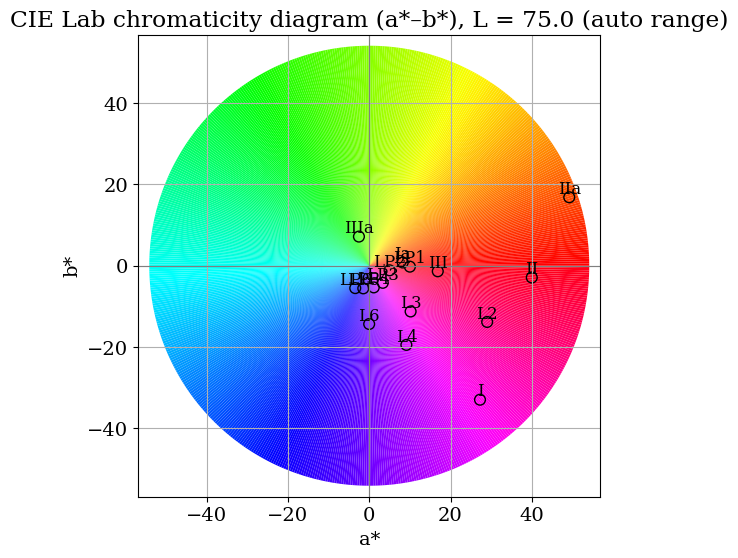

In [4]:
#@title Cell 4: Plot filled CIE Lab chromaticity circle (auto range, empty markers, using GLOBAL_L)

# Extract a*, b*, and IDs
a_vals = df['a*'].values
b_vals = df['b*'].values
ids = df['ID'].astype(str).values

# Define the chromaticity circle radius with margin
R = max(np.max(np.abs(a_vals)), np.max(np.abs(b_vals))) * 1.1
if R == 0:
    R = 50  # fallback

theta = np.linspace(0, 2 * np.pi, 600)
circle_a = R * np.cos(theta)
circle_b = R * np.sin(theta)

fig, ax = plt.subplots()
ax.set_aspect('equal')

# Create a colormap for the filled circle (hue vs angle)
circle_colors = plt.get_cmap('hsv')(theta / (2 * np.pi))

# Use a PolyCollection to fill the circle with varying color
from matplotlib.collections import PolyCollection
segments = []
colors = []
for i in range(len(theta) - 1):
    seg = [(0, 0), (circle_a[i], circle_b[i]), (circle_a[i+1], circle_b[i+1])]
    segments.append(seg)
    colors.append(circle_colors[i])
poly = PolyCollection(segments, facecolors=colors, edgecolors=None)
ax.add_collection(poly)

# Plot sample points with empty circle markers and annotate with IDs
ax.scatter(a_vals, b_vals, facecolors='none', edgecolors='black', s=60, marker='o')

marker_font_size = max(GLOBAL_FONT_SIZE - 2, 1)
for a, b, label in zip(a_vals, b_vals, ids):
    ax.text(a, b, label, fontsize=marker_font_size, ha='center', va='bottom')

# Axes labels and title including current GLOBAL_L
ax.set_xlabel('a*')
ax.set_ylabel('b*')
ax.set_title(f'CIE Lab chromaticity diagram (a*–b*), L = {GLOBAL_L} (auto range)')

# Add horizontal/vertical axes
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

# Set limits with a small margin
margin = 0.05 * R
ax.set_xlim(-R - margin, R + margin)
ax.set_ylim(-R - margin, R + margin)

plt.show()


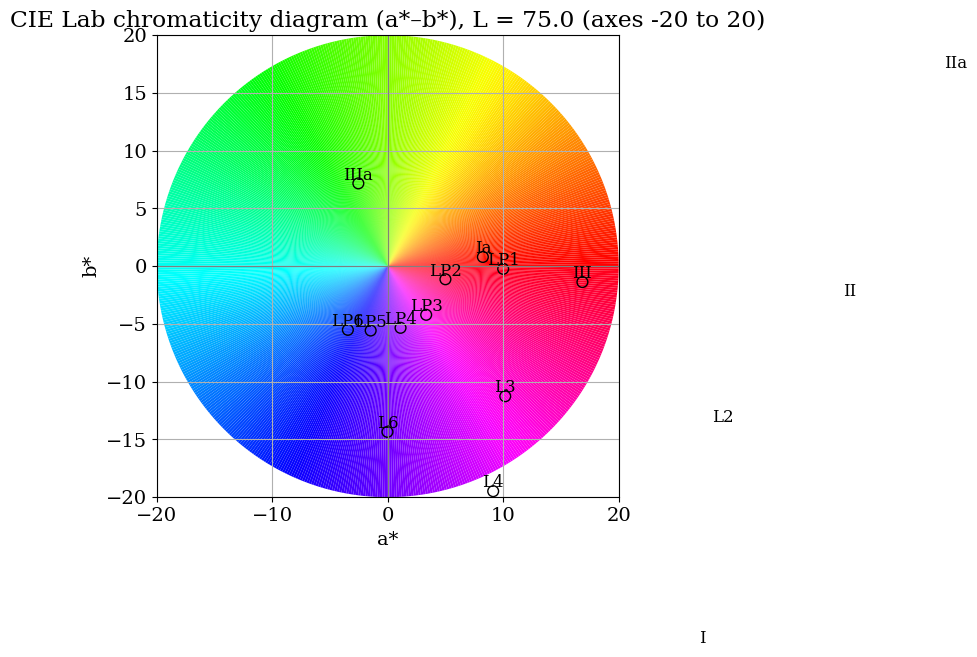

In [5]:
#@title Cell 5: Plot filled CIE Lab chromaticity circle (fixed range -20 to 20, empty markers, using GLOBAL_L)

# Extract a*, b*, and IDs
a_vals = df['a*'].values
b_vals = df['b*'].values
ids = df['ID'].astype(str).values

# Fixed radius corresponding to 20 (to match axis range)
R_fixed = 20.0
theta = np.linspace(0, 2 * np.pi, 600)
circle_a_fixed = R_fixed * np.cos(theta)
circle_b_fixed = R_fixed * np.sin(theta)

fig, ax = plt.subplots()
ax.set_aspect('equal')

# Colored filled circle using hsv colormap over angle
circle_colors_fixed = plt.get_cmap('hsv')(theta / (2 * np.pi))
segments_fixed = []
colors_fixed = []
for i in range(len(theta) - 1):
    seg = [(0, 0), (circle_a_fixed[i], circle_b_fixed[i]), (circle_a_fixed[i+1], circle_b_fixed[i+1])]
    segments_fixed.append(seg)
    colors_fixed.append(circle_colors_fixed[i])
poly_fixed = PolyCollection(segments_fixed, facecolors=colors_fixed, edgecolors=None)
ax.add_collection(poly_fixed)

# Plot sample points with empty circle markers and annotate with IDs
ax.scatter(a_vals, b_vals, facecolors='none', edgecolors='black', s=60, marker='o')

marker_font_size = max(GLOBAL_FONT_SIZE - 2, 1)
for a, b, label in zip(a_vals, b_vals, ids):
    ax.text(a, b, label, fontsize=marker_font_size, ha='center', va='bottom')

# Axes labels and title including current GLOBAL_L
ax.set_xlabel('a*')
ax.set_ylabel('b*')
ax.set_title(f'CIE Lab chromaticity diagram (a*–b*), L = {GLOBAL_L} (axes -20 to 20)')

# Add horizontal/vertical axes
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

# Fixed axis limits from -20 to 20
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)

plt.show()
